In [1]:
#任务 1：基础实现 ——LSTM 完成 IMDb 影评情感分类

import os
import re
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --------------------------
# 1. 配置路径（请根据实际情况修改）
# --------------------------
data_root = "/home/hexiaoya/tensorflow_datasets/imdb_reviews/plain_text/1.0.0/aclImdb"

# --------------------------
# 2. 工具函数：文本清洗、数据打乱
# --------------------------
def clean_text(text):
    """清洗文本噪声"""
    text = re.sub(r'<.*?>', '', text)  # 移除HTML标签
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # 移除非字母字符
    text = text.lower()  # 转为小写
    text = re.sub(r'\s+', ' ', text).strip()  # 合并多余空格
    return text

def shuffle_data(texts, labels):
    """打乱数据，保持文本-标签对应"""
    indices = list(range(len(texts)))
    random.shuffle(indices)
    return [texts[i] for i in indices], [labels[i] for i in indices]

# --------------------------
# 3. 加载本地数据集（修正后）
# --------------------------
def load_imdb_from_local(data_root, split="train"):
    texts = []
    labels = []
    for label, folder in [(1, "pos"), (0, "neg")]:
        folder_path = os.path.join(data_root, split, folder)
        print(f"正在读取：{folder_path}")
        if not os.path.exists(folder_path):
            print(f"❌ 警告：路径不存在 - {folder_path}")
            continue
        # 读取文件夹下所有文件（避免因文件过多卡顿，可限制数量测试）
        file_count = 0
        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            try:
                with open(file_path, "r", encoding="utf-8") as f:
                    text = f.read().strip()
            except UnicodeDecodeError:
                with open(file_path, "r", encoding="latin-1") as f:
                    text = f.read().strip()
            # 清洗文本
            text = clean_text(text)
            texts.append(text)
            labels.append(label)
            file_count += 1
        print(f"✅ 成功读取 {folder} 文件夹：{file_count} 条数据")
    return texts, labels

# 加载数据
train_texts, train_labels = load_imdb_from_local(data_root, split="train")
test_texts, test_labels = load_imdb_from_local(data_root, split="test")

# 打乱训练集
train_texts, train_labels = shuffle_data(train_texts, train_labels)

# --------------------------
# 4. 验证数据有效性（必看！）
# --------------------------
print(f"\n📊 数据加载结果验证")
print(f"训练集文本数：{len(train_texts)}（目标：25000）")
print(f"测试集文本数：{len(test_texts)}（目标：25000）")
print(f"训练集正面标签数：{np.sum(np.array(train_labels) == 1)}（目标：~12500）")
print(f"训练集负面标签数：{np.sum(np.array(train_labels) == 0)}（目标：~12500）")
print(f"\n📝 清洗后示例文本：{train_texts[0][:100]}...")
print(f"🏷️  示例标签：{train_labels[0]}")

# --------------------------
# 5. 文本编码（Tokenizer+pad_sequences）
# --------------------------
# 初始化Tokenizer（保留10000个高频词）
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")  # oov_token处理未见过的词
tokenizer.fit_on_texts(train_texts)  # 拟合训练集文本

# 编码+统一序列长度
train_seqs = tokenizer.texts_to_sequences(train_texts)
train_padded = pad_sequences(train_seqs, maxlen=200, padding='post', truncating='post')
test_seqs = tokenizer.texts_to_sequences(test_texts)
test_padded = pad_sequences(test_seqs, maxlen=200, padding='post', truncating='post')

# 转换标签为TensorFlow可处理的格式
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

# --------------------------
# 6. 构建数据集（原生API，稳定无bug）
# --------------------------
batch_size = 32
train_ds = tf.data.Dataset.from_tensor_slices((train_padded, train_labels))
train_ds = train_ds.shuffle(25000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_padded, test_labels))
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# 最终验证数据集形状
for texts, labels in train_ds.take(1):
    print(f"\n✅ 数据集形状验证")
    print(f"批量文本形状：{texts.shape}（batch_size, seq_len）")  # (32, 200)
    print(f"批量标签形状：{labels.shape}（batch_size,）")  # (32,)
    print(f"序列中非0元素占比：{(texts.numpy() != 0).sum() / (32*200):.2f}（目标>0.5）")

2025-11-26 18:01:53.533137: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-26 18:01:53.533278: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-26 18:01:53.537729: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


正在读取：/home/hexiaoya/tensorflow_datasets/imdb_reviews/plain_text/1.0.0/aclImdb/train/pos
✅ 成功读取 pos 文件夹：12500 条数据
正在读取：/home/hexiaoya/tensorflow_datasets/imdb_reviews/plain_text/1.0.0/aclImdb/train/neg
✅ 成功读取 neg 文件夹：12500 条数据
正在读取：/home/hexiaoya/tensorflow_datasets/imdb_reviews/plain_text/1.0.0/aclImdb/test/pos
✅ 成功读取 pos 文件夹：12500 条数据
正在读取：/home/hexiaoya/tensorflow_datasets/imdb_reviews/plain_text/1.0.0/aclImdb/test/neg
✅ 成功读取 neg 文件夹：12500 条数据

📊 数据加载结果验证
训练集文本数：25000（目标：25000）
测试集文本数：25000（目标：25000）
训练集正面标签数：12500（目标：~12500）
训练集负面标签数：12500（目标：~12500）

📝 清洗后示例文本：mild spoilers contained herein im spoiling this film to save you the trouble of having to watch it j...
🏷️  示例标签：0

✅ 数据集形状验证
批量文本形状：(32, 200)（batch_size, seq_len）
批量标签形状：(32,)（batch_size,）
序列中非0元素占比：0.76（目标>0.5）


In [2]:
# 模型参数（与原PyTorch项目保持一致，确保对比公平）
vocab_size = 10000  # 词汇表大小
embedding_dim = 100  # 词嵌入维度
hidden_dim = 128     # LSTM隐藏层维度
output_dim = 1       # 输出维度（二分类，用sigmoid激活）

# 构建LSTM模型（Sequential API，简洁直观）
lstm_model = tf.keras.Sequential([
    # 1. 词嵌入层：将整数序列转为低维向量（input_length=200对应序列长度）
    tf.keras.layers.Embedding(
        input_dim=vocab_size, 
        output_dim=embedding_dim, 
        input_length=200,
        mask_zero=True  # 忽略填充值（<pad>对应的0），避免影响LSTM计算
    ),
    # 2. LSTM层：hidden_dim=128，仅返回最后时刻的隐藏状态（return_sequences=False）
    tf.keras.layers.LSTM(units=hidden_dim, return_sequences=False),
    # 3. 输出层：二分类用sigmoid激活，输出概率（0~1）
    tf.keras.layers.Dense(units=output_dim, activation='sigmoid')
])

# 查看模型结构
lstm_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 200, 100)          1000000   
                                                                 
 lstm (LSTM)                 (None, 128)               117248    
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                                 
Total params: 1117377 (4.26 MB)
Trainable params: 1117377 (4.26 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [3]:
# 编译模型：设置优化器、损失函数、评估指标
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),  # 二分类交叉熵（标签为整数，无需one-hot）
    metrics=[tf.keras.metrics.BinaryAccuracy(name='accuracy')]  # 评估准确率
)

# 定义回调函数（可选，用于早停、模型保存）
callbacks = [
    # 早停：验证损失连续3轮不下降则停止训练，避免过拟合
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    ),
    # 保存最优模型（基于验证准确率）
    tf.keras.callbacks.ModelCheckpoint(
        filepath='lstm_imdb_best.h5', monitor='val_accuracy', save_best_only=True
    )
]

# 开始训练（epochs=10，与原项目一致；validation_data=test_ds用于验证）
history_lstm = lstm_model.fit(
    x=train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1  # 显示训练过程（1=进度条，2=每轮一行）
)

# 评估最优模型（加载保存的最佳权重）
best_lstm = tf.keras.models.load_model('lstm_imdb_best.h5')
test_loss, test_acc = best_lstm.evaluate(test_ds, verbose=0)
print(f"\nLSTM模型测试准确率：{test_acc:.4f}")

Epoch 1/10
  1/782 [..............................] - ETA: 37:15 - loss: 0.6923 - accuracy: 0.5625

I0000 00:00:1764151337.431546   66966 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 [==============================] - 48s 57ms/step - loss: 0.5234 - accuracy: 0.7427 - val_loss: 0.4235 - val_accuracy: 0.8154
Epoch 2/10
  4/782 [..............................] - ETA: 15s - loss: 0.3220 - accuracy: 0.8984

/home/hexiaoya/miniconda3/envs/ai/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


782/782 [==============================] - 24s 31ms/step - loss: 0.3222 - accuracy: 0.8693 - val_loss: 0.3718 - val_accuracy: 0.8481
Epoch 3/10
782/782 [==============================] - 24s 31ms/step - loss: 0.2324 - accuracy: 0.9130 - val_loss: 0.4166 - val_accuracy: 0.8400
Epoch 4/10
782/782 [==============================] - 21s 27ms/step - loss: 0.1709 - accuracy: 0.9373 - val_loss: 0.4481 - val_accuracy: 0.8216
Epoch 5/10
782/782 [==============================] - 23s 30ms/step - loss: 0.1614 - accuracy: 0.9406 - val_loss: 0.4953 - val_accuracy: 0.8357

LSTM模型测试准确率：0.8481


In [4]:
#任务 2：对比实验 ——RNN vs LSTM vs GRU（TensorFlow 实现）

import tensorflow as tf
tf.config.optimizer.set_jit(True)

# 1. 定义模型构建函数（统一参数，仅替换循环层）
def build_recurrent_model(model_type, vocab_size, embedding_dim, hidden_dim, output_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(
            input_dim=vocab_size, output_dim=embedding_dim, input_length=200, mask_zero=True
        ),
        # 根据model_type选择循环层
        tf.keras.layers.SimpleRNN(units=hidden_dim, return_sequences=False) if model_type == 'rnn'
        else tf.keras.layers.GRU(units=hidden_dim, return_sequences=False) if model_type == 'gru'
        else tf.keras.layers.LSTM(units=hidden_dim, return_sequences=False),
        tf.keras.layers.Dense(units=output_dim, activation='sigmoid')
    ])
    # 编译模型（参数与LSTM一致）
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[tf.keras.metrics.BinaryAccuracy(name='accuracy')]
    )
    return model

# 2. 分别训练RNN、GRU模型
# 训练RNN
rnn_model = build_recurrent_model('rnn', vocab_size, embedding_dim, hidden_dim, output_dim)
history_rnn = rnn_model.fit(
    train_ds, validation_data=test_ds, epochs=10, callbacks=callbacks, verbose=1
)
rnn_test_loss, rnn_test_acc = rnn_model.evaluate(test_ds, verbose=0)

# 训练GRU
gru_model = build_recurrent_model('gru', vocab_size, embedding_dim, hidden_dim, output_dim)
history_gru = gru_model.fit(
    train_ds, validation_data=test_ds, epochs=10, callbacks=callbacks, verbose=1
)
gru_test_loss, gru_test_acc = gru_model.evaluate(test_ds, verbose=0)

# 3. 对比实验结果（打印准确率）
print("\n=== 模型准确率对比 ===")
print(f"RNN测试准确率：{rnn_test_acc:.4f}")
print(f"GRU测试准确率：{gru_test_acc:.4f}")
print(f"LSTM测试准确率：{test_acc:.4f}")


Epoch 1/10
782/782 [==============================] - 263s 334ms/step - loss: 0.6934 - accuracy: 0.5223 - val_loss: 0.6842 - val_accuracy: 0.5320
Epoch 2/10
782/782 [==============================] - 259s 331ms/step - loss: 0.6576 - accuracy: 0.5999 - val_loss: 0.6588 - val_accuracy: 0.5935
Epoch 3/10
782/782 [==============================] - 379s 484ms/step - loss: 0.5937 - accuracy: 0.6872 - val_loss: 0.6170 - val_accuracy: 0.6740
Epoch 4/10
782/782 [==============================] - 319s 408ms/step - loss: 0.5349 - accuracy: 0.7406 - val_loss: 0.6067 - val_accuracy: 0.6958
Epoch 5/10
782/782 [==============================] - 287s 367ms/step - loss: 0.5021 - accuracy: 0.7640 - val_loss: 0.6179 - val_accuracy: 0.6923
Epoch 6/10
782/782 [==============================] - 313s 400ms/step - loss: 0.4595 - accuracy: 0.7958 - val_loss: 0.8446 - val_accuracy: 0.6653
Epoch 7/10
782/782 [==============================] - 313s 400ms/step - loss: 0.4712 - accuracy: 0.7756 - val_loss: 0.6192 -

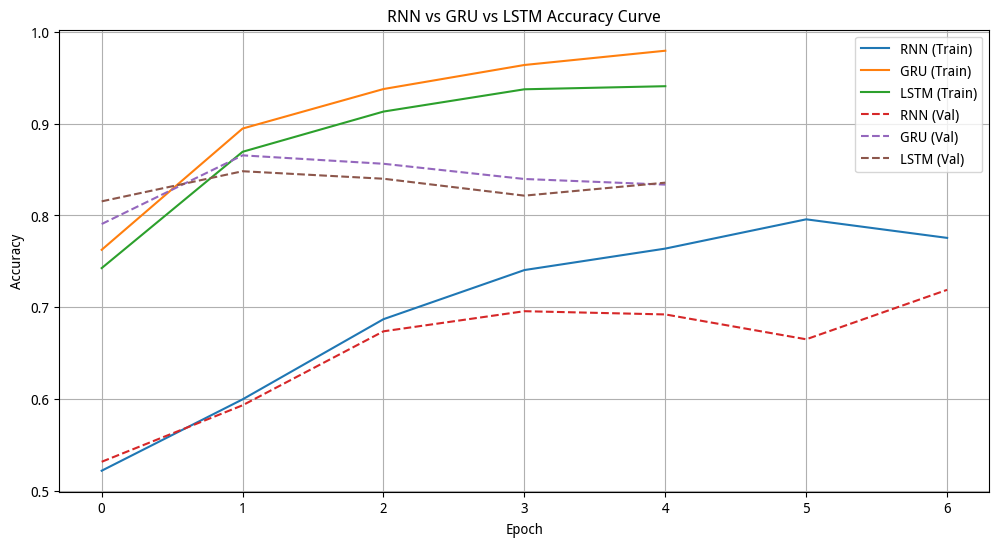

In [5]:
# 4. 可视化训练曲线（epoch-准确率）
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 6))
# 训练准确率
plt.plot(history_rnn.history['accuracy'], label='RNN (Train)')
plt.plot(history_gru.history['accuracy'], label='GRU (Train)')
plt.plot(history_lstm.history['accuracy'], label='LSTM (Train)')
# 验证准确率
plt.plot(history_rnn.history['val_accuracy'], label='RNN (Val)', linestyle='--')
plt.plot(history_gru.history['val_accuracy'], label='GRU (Val)', linestyle='--')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM (Val)', linestyle='--')
# 图表设置
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('RNN vs GRU vs LSTM Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, GRU, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def build_lstm_functional(vocab_size, embedding_dim, hidden_dim, output_dim, max_seq_len=200):
    # ① 定义输入层：shape=(max_seq_len,)（每个样本是长度为200的词索引序列）
    inputs = Input(shape=(max_seq_len,), name="text_input")
    
    # ② 词嵌入层：mask_zero=True忽略填充符（0）
    x = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_seq_len,
        mask_zero=True,
        name="embedding_layer"
    )(inputs)  # 显式连接：输入层→嵌入层
    
    # ③ LSTM层：return_sequences=False（分类任务，仅需最后时刻隐藏状态）
    x = LSTM(units=hidden_dim, return_sequences=False, name="lstm_layer")(x)  # 嵌入层→LSTM层
    
    # （可选）添加Dropout层防止过拟合（根据需要启用）
    # x = Dropout(0.5, name="dropout_layer")(x)
    
    # ④ 输出层：二分类用sigmoid激活
    outputs = Dense(units=output_dim, activation="sigmoid", name="output_layer")(x)  # LSTM层→输出层
    
    # ⑤ 封装模型：指定输入和输出
    model = Model(inputs=inputs, outputs=outputs, name="LSTM_Functional_Model")
    
    # 编译模型（与Sequential版本参数一致）
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy")]
    )
    return model

# 初始化LSTM模型
lstm_model = build_lstm_functional(vocab_size=10000, embedding_dim=100, hidden_dim=128, output_dim=1)

# 查看模型结构（对比Sequential版本，参数数量完全一致）
lstm_model.summary()

Model: "LSTM_Functional_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_input (InputLayer)     [(None, 200)]             0         
                                                                 
 embedding_layer (Embedding  (None, 200, 100)          1000000   
 )                                                               
                                                                 
 lstm_layer (LSTM)           (None, 128)               117248    
                                                                 
 output_layer (Dense)        (None, 1)                 129       
                                                                 
Total params: 1117377 (4.26 MB)
Trainable params: 1117377 (4.26 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [7]:
def build_gru_functional(vocab_size, embedding_dim, hidden_dim, output_dim, max_seq_len=200):
    # ① 输入层（与LSTM完全一致）
    inputs = Input(shape=(max_seq_len,), name="text_input")
    
    # ② 嵌入层（与LSTM完全一致）
    x = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_seq_len,
        mask_zero=True,
        name="embedding_layer"
    )(inputs)
    
    # ③ GRU层（仅替换LSTM为GRU，参数不变）
    x = GRU(units=hidden_dim, return_sequences=False, name="gru_layer")(x)
    
    # （可选）Dropout层
    # x = Dropout(0.5, name="dropout_layer")(x)
    
    # ④ 输出层（与LSTM完全一致）
    outputs = Dense(units=output_dim, activation="sigmoid", name="output_layer")(x)
    
    # ⑤ 封装模型
    model = Model(inputs=inputs, outputs=outputs, name="GRU_Functional_Model")
    
    # 编译（与LSTM参数一致）
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy")]
    )
    return model

# 初始化GRU模型
gru_model = build_gru_functional(vocab_size=10000, embedding_dim=100, hidden_dim=128, output_dim=1)

# 查看GRU模型结构
gru_model.summary()

Model: "GRU_Functional_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_input (InputLayer)     [(None, 200)]             0         
                                                                 
 embedding_layer (Embedding  (None, 200, 100)          1000000   
 )                                                               
                                                                 
 gru_layer (GRU)             (None, 128)               88320     
                                                                 
 output_layer (Dense)        (None, 1)                 129       
                                                                 
Total params: 1088449 (4.15 MB)
Trainable params: 1088449 (4.15 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [8]:
# 定义回调函数（早停+模型保存）
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ModelCheckpoint(filepath="lstm_functional_best.h5", monitor="val_accuracy", save_best_only=True)
]

# 训练LSTM模型
print("=== 训练LSTM模型 ===")
history_lstm = lstm_model.fit(
    x=train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

# 训练GRU模型（更换回调函数保存路径）
callbacks_gru = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ModelCheckpoint(filepath="gru_functional_best.h5", monitor="val_accuracy", save_best_only=True)
]

print("\n=== 训练GRU模型 ===")
history_gru = gru_model.fit(
    x=train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=callbacks_gru,
    verbose=1
)

=== 训练LSTM模型 ===
Epoch 1/10
782/782 [==============================] - 49s 57ms/step - loss: 0.5085 - accuracy: 0.7526 - val_loss: 0.4109 - val_accuracy: 0.8304
Epoch 2/10
  1/782 [..............................] - ETA: 1:36 - loss: 0.2505 - accuracy: 0.9375

/home/hexiaoya/miniconda3/envs/ai/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


782/782 [==============================] - 24s 31ms/step - loss: 0.3152 - accuracy: 0.8742 - val_loss: 0.3614 - val_accuracy: 0.8459
Epoch 3/10
782/782 [==============================] - 27s 34ms/step - loss: 0.2380 - accuracy: 0.9100 - val_loss: 0.3977 - val_accuracy: 0.8378
Epoch 4/10
782/782 [==============================] - 23s 29ms/step - loss: 0.1795 - accuracy: 0.9339 - val_loss: 0.4455 - val_accuracy: 0.8392
Epoch 5/10
782/782 [==============================] - 23s 30ms/step - loss: 0.1410 - accuracy: 0.9485 - val_loss: 0.5459 - val_accuracy: 0.8321

=== 训练GRU模型 ===
Epoch 1/10
782/782 [==============================] - 43s 53ms/step - loss: 0.4513 - accuracy: 0.7846 - val_loss: 0.3575 - val_accuracy: 0.8469
Epoch 2/10
782/782 [==============================] - 26s 33ms/step - loss: 0.2624 - accuracy: 0.8974 - val_loss: 0.3341 - val_accuracy: 0.8560
Epoch 3/10
782/782 [==============================] - 24s 31ms/step - loss: 0.1726 - accuracy: 0.9385 - val_loss: 0.4003 - val_acc

In [9]:
# 评估LSTM模型
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(test_ds, verbose=0)
print(f"\nLSTM模型测试准确率：{lstm_test_acc:.4f}")

# 评估GRU模型
gru_test_loss, gru_test_acc = gru_model.evaluate(test_ds, verbose=0)
print(f"GRU模型测试准确率：{gru_test_acc:.4f}")


LSTM模型测试准确率：0.8459
GRU模型测试准确率：0.8560
